In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.shape

(7043, 21)

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [11]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Here Senior citizen,Tenure,Monthly charges are the only int values,other than all are objects.

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Summary**\
16% customers are senior citizens\
average customer stays around 32 months\
average monthly bill = $64\
\
Standarad deviation shows how spread the data is:\
Low std:value close to mean\
High std:values widely spread\
\
Tenure std is 24 means customer stay duration varies a lot\
\
Q1:\
25% customers stayed less than 9 months\
25% customers pay less than 35\
\
**If mean and median are nearly equal then there is no outliers**
\
min = 0:new customers\
max = 72:loyal customers

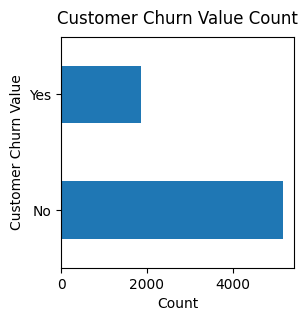

In [24]:
df['Churn'].value_counts().plot(kind='barh',figsize=(3,3))
plt.xlabel("Count")
plt.ylabel("Customer Churn Value")
plt.title("Customer Churn Value Count",y=1.02);

In [25]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Churn Percentage

In [26]:
100*df['Churn'].value_counts()/len(df['Churn'])

,count
Churn,
No,73.463013
Yes,26.536987


In [27]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


Data is Highly Imbalanced:73:27\
Balanced Data:50-50\
Due to more no values,the model is become biased and the model always predicts the "No",hence it id difficult to detect the churned customers.

In [28]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


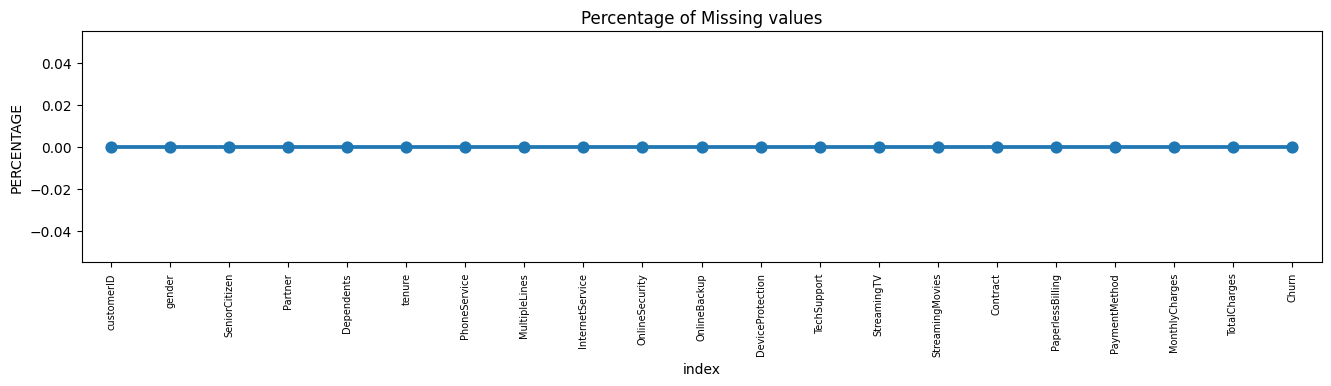

In [35]:
missing = pd.DataFrame((df.isnull().sum()) * 100 / df.shape[0]).reset_index()
plt.figure(figsize=(16,3))
ax = sns.pointplot(
    x='index',
    y=0,
    data=missing
)
plt.xticks(rotation=90, fontsize=7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.show()

**Data Cleaning**

In [36]:
df_dummy=df.copy()

In [37]:
df_dummy.TotalCharges=pd.to_numeric(df_dummy.TotalCharges,errors='coerce')
df_dummy.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [38]:
df_dummy.dropna(inplace=True)

In [39]:
df_dummy.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [40]:
df_dummy['tenure'].max()

72

Creating the bin values

In [42]:
labels = [
"{0} - {1}".format(i, i + 11)
for i in range(1,72,12)
]
df_dummy['tenure_group'] = pd.cut(df_dummy.tenure, range(1, 80, 12), retbins=False, labels=labels)

In [44]:
df_dummy['tenure_group'].value_counts()


,count
tenure_group,
1 - 12,1671
61 - 72,1331
13 - 24,994
49 - 60,842
25 - 36,818
37 - 48,763


In [46]:
df_dummy.drop(columns=['customerID','tenure'],axis=1,inplace=True)

In [47]:
df_dummy.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,NaN
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


In [48]:
df_dummy.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0


**Univariate Analysis**\
Take churn catagorical colum and analyse it


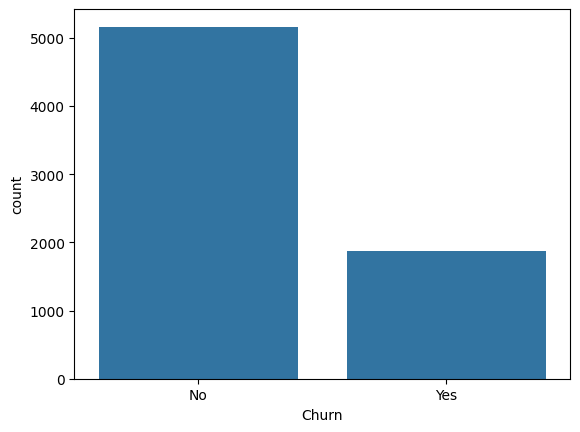

In [51]:
sns.countplot(data=df_dummy,x='Churn');

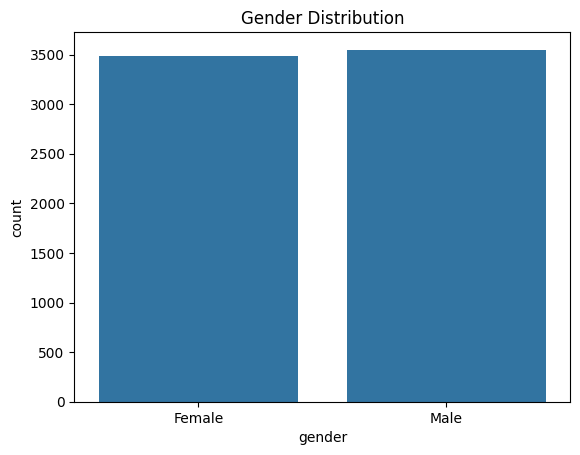

In [52]:
sns.countplot(
    data=df_dummy,
    x='gender'
)

plt.title("Gender Distribution")
plt.show()

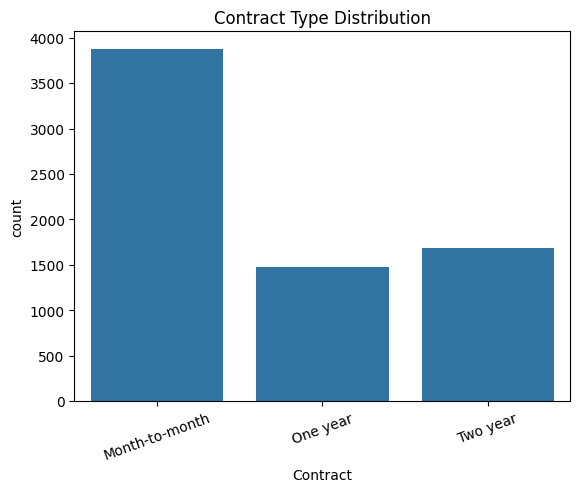

In [53]:
sns.countplot(
    data=df_dummy,
    x='Contract'
)

plt.title("Contract Type Distribution")
plt.xticks(rotation=20)
plt.show()

**Bivarite**\
Both are categorical

<Axes: xlabel='gender', ylabel='count'>

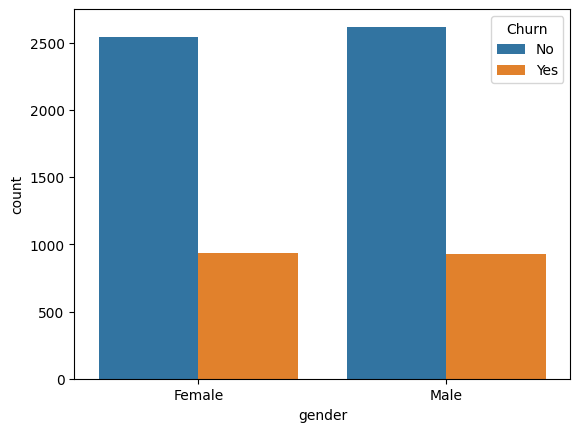

In [56]:
sns.countplot(data=df_dummy,x='gender',hue='Churn')


**Bivariate**\
One catagorical and numerical values

<Axes: xlabel='MonthlyCharges', ylabel='count'>

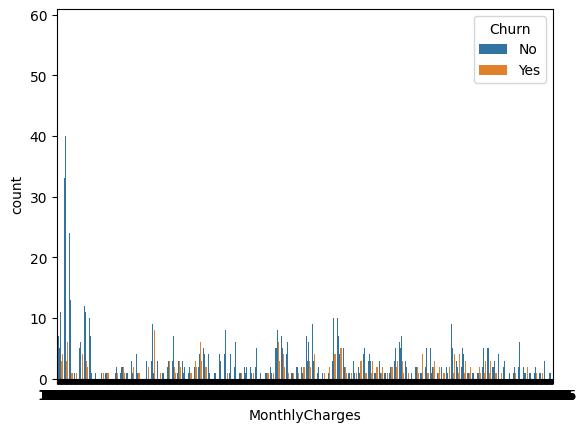

In [59]:
sns.countplot(data=df_dummy,x='MonthlyCharges',hue='Churn')

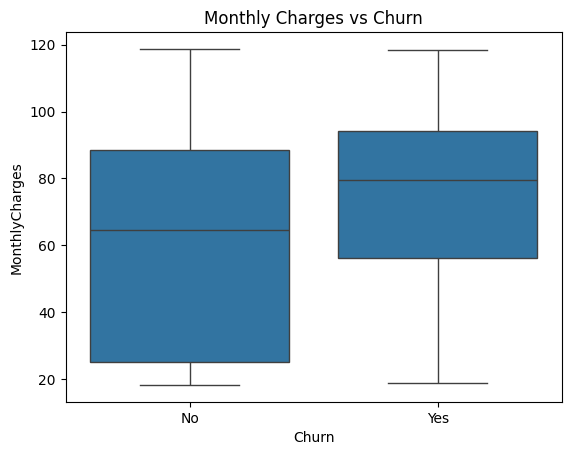

In [60]:
sns.boxplot(
    data=df_dummy,
    x='Churn',
    y='MonthlyCharges'
)

plt.title("Monthly Charges vs Churn")
plt.show()

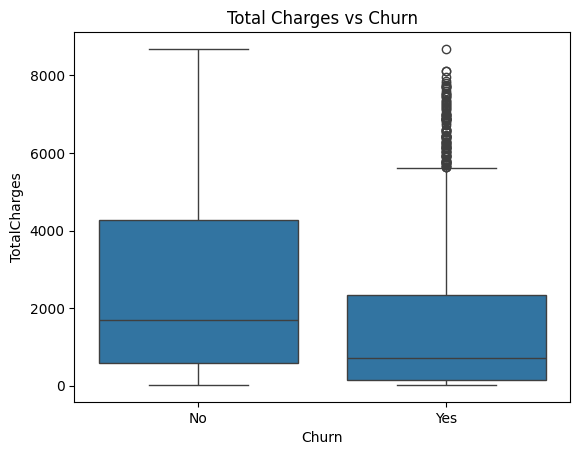

In [61]:
sns.boxplot(
    data=df_dummy,
    x='Churn',
    y='TotalCharges'
)

plt.title("Total Charges vs Churn")
plt.show()

<Axes: xlabel='SeniorCitizen', ylabel='count'>

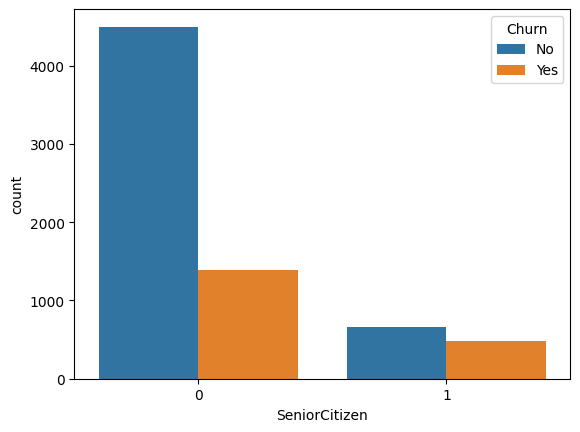

In [64]:
sns.countplot(data=df_dummy,x='SeniorCitizen',hue='Churn')

**Numerical vs Numerical**

<Axes: xlabel='Partner', ylabel='count'>

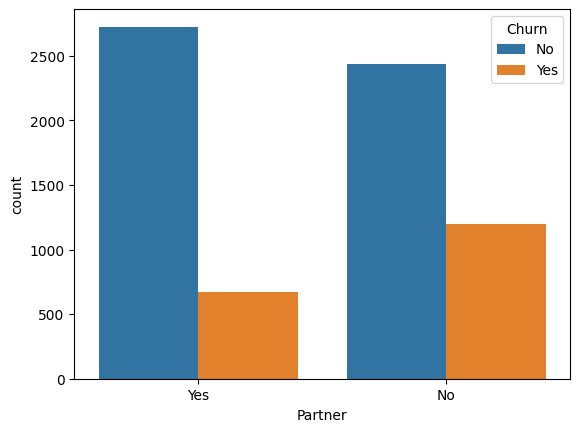

In [57]:
sns.countplot(data=df_dummy,x='Partner',hue='Churn')

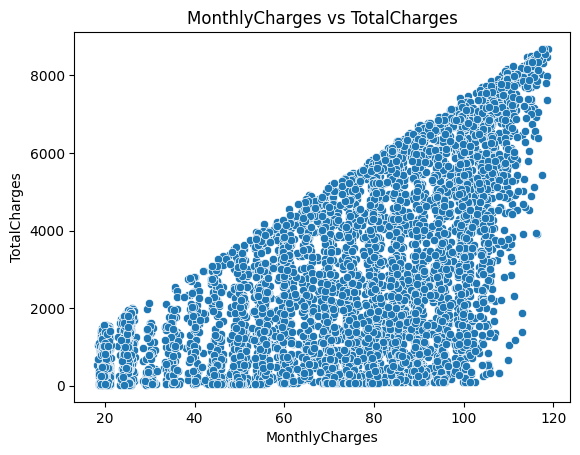

In [62]:
sns.scatterplot(
    data=df_dummy,
    x='MonthlyCharges',
    y='TotalCharges'
)

plt.title("MonthlyCharges vs TotalCharges")
plt.show()

Original Data\
     ↓\
EDA\
     ↓\
Cleaning\
     ↓\
Train-Test Split\
     ↓\
SMOTE on Training Data Only\
     ↓\
Train Model\
     ↓\
Evaluate Model

EDA → Keep original data

ML Training → Balance the data

WE just onlu analyse the data by use these visualizations ,\
in the training phase we use to balaned the plots to get the accurate model